<a href="https://colab.research.google.com/github/saadkhokar-creator/231A019-NLP-Experiments/blob/main/NLP_MINI_PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip -q install nltk wordcloud joblib

In [6]:
import re
import string
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

warnings.filterwarnings("ignore")

nltk.download("punkt")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [8]:
from google.colab import files

uploaded = files.upload()

Saving train.csv to train.csv


In [9]:
data = pd.read_csv("train.csv")

print("Dataset Shape:", data.shape)

data.head()

Dataset Shape: (7613, 5)


,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


In [10]:
print(data.info())

print("\nMissing Values\n")

print(data.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        7613 non-null   int64 
 1   keyword   7552 non-null   object
 2   location  5080 non-null   object
 3   text      7613 non-null   object
 4   target    7613 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 297.5+ KB
None

Missing Values

id             0
keyword       61
location    2533
text           0
target         0
dtype: int64


In [11]:
data = data[["text", "target"]]

data.head()

,text,target
0,Our Deeds are the Reason of this #earthquake M...,1
1,Forest fire near La Ronge Sask. Canada,1
2,All residents asked to 'shelter in place' are ...,1
3,"13,000 people receive #wildfires evacuation or...",1
4,Just got sent this photo from Ruby #Alaska as ...,1


In [12]:
data.dropna(inplace=True)

data.reset_index(drop=True, inplace=True)

print("Dataset Shape:", data.shape)

Dataset Shape: (7613, 2)


target
0    4342
1    3271
Name: count, dtype: int64


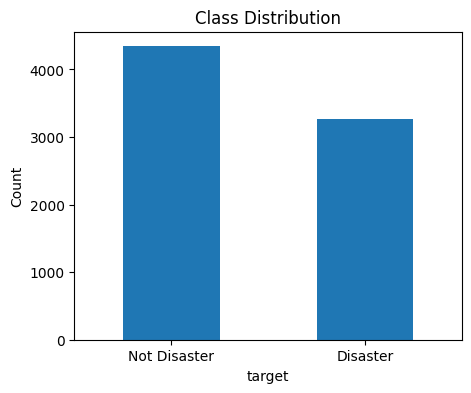

In [13]:
print(data["target"].value_counts())

plt.figure(figsize=(5,4))

data["target"].value_counts().plot(kind="bar")

plt.xticks([0,1],["Not Disaster","Disaster"], rotation=0)

plt.ylabel("Count")

plt.title("Class Distribution")

plt.show()

In [14]:
stop_words = set(stopwords.words("english"))

lemmatizer = WordNetLemmatizer()

In [15]:
import re
import string
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):

    text = str(text).lower()

    text = re.sub(r"http\S+", " ", text)
    text = re.sub(r"www\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"#", "", text)
    text = re.sub(r"\d+", " ", text)

    text = text.translate(str.maketrans("", "", string.punctuation))

    # Simple tokenization
    tokens = text.split()

    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words and len(word) > 2
    ]

    return " ".join(tokens)

In [16]:
print("Cleaning Tweets...")

data["clean_text"] = data["text"].apply(clean_text)

print("ok")

Cleaning Tweets...
ok


In [17]:
data[["text","clean_text","target"]].head(10)

,text,clean_text,target
0,Our Deeds are the Reason of this #earthquake M...,deed reason earthquake may allah forgive,1
1,Forest fire near La Ronge Sask. Canada,forest fire near ronge sask canada,1
2,All residents asked to 'shelter in place' are ...,resident asked shelter place notified officer ...,1
3,"13,000 people receive #wildfires evacuation or...",people receive wildfire evacuation order calif...,1
4,Just got sent this photo from Ruby #Alaska as ...,got sent photo ruby alaska smoke wildfire pour...,1
5,#RockyFire Update => California Hwy. 20 closed...,rockyfire update california hwy closed directi...,1
6,#flood #disaster Heavy rain causes flash flood...,flood disaster heavy rain cause flash flooding...,1
7,I'm on top of the hill and I can see a fire in...,top hill see fire wood,1
8,There's an emergency evacuation happening now ...,there emergency evacuation happening building ...,1
9,I'm afraid that the tornado is coming to our a...,afraid tornado coming area,1


In [18]:
data = data[data["clean_text"].str.len() > 0]

data.reset_index(drop=True, inplace=True)

print(data.shape)

(7612, 3)


In [19]:
import os

os.makedirs("outputs", exist_ok=True)

data.to_csv("outputs/cleaned_tweets.csv", index=False)

print("Clean dataset saved ")

Clean dataset saved 


In [20]:
import os
import joblib
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

In [21]:
data = pd.read_csv("outputs/cleaned_tweets.csv")

print("Dataset Loaded Successfully")

data.head()

Dataset Loaded Successfully


,text,target,clean_text
0,Our Deeds are the Reason of this #earthquake M...,1,deed reason earthquake may allah forgive
1,Forest fire near La Ronge Sask. Canada,1,forest fire near ronge sask canada
2,All residents asked to 'shelter in place' are ...,1,resident asked shelter place notified officer ...
3,"13,000 people receive #wildfires evacuation or...",1,people receive wildfire evacuation order calif...
4,Just got sent this photo from Ruby #Alaska as ...,1,got sent photo ruby alaska smoke wildfire pour...


In [22]:
X = data["clean_text"]

y = data["target"]

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Samples :", len(X_train))
print("Testing Samples  :", len(X_test))

Training Samples : 6089
Testing Samples  : 1523


In [24]:
os.makedirs("models", exist_ok=True)

In [25]:
MODEL_PATH = "models/logistic_model.pkl"

VECTORIZER_PATH = "models/tfidf_vectorizer.pkl"

In [26]:
if os.path.exists(MODEL_PATH) and os.path.exists(VECTORIZER_PATH):

    print("Loading existing model...")

    model = joblib.load(MODEL_PATH)

    vectorizer = joblib.load(VECTORIZER_PATH)

    X_train_tfidf = vectorizer.transform(X_train)

    X_test_tfidf = vectorizer.transform(X_test)

    print("Model Loaded Successfully!")

else:

    print("No saved model found.")

    print("Training a new model...")

    vectorizer = TfidfVectorizer(
        max_features=5000,
        ngram_range=(1,2),
        min_df=2,
        max_df=0.95
    )

    X_train_tfidf = vectorizer.fit_transform(X_train)

    X_test_tfidf = vectorizer.transform(X_test)

    model = LogisticRegression(
        max_iter=1000,
        random_state=42
    )

    model.fit(X_train_tfidf, y_train)

    joblib.dump(model, MODEL_PATH)

    joblib.dump(vectorizer, VECTORIZER_PATH)

    print("Training Completed!")

    print("Model Saved Successfully!")

No saved model found.
Training a new model...
Training Completed!
Model Saved Successfully!


In [27]:
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve
)

In [28]:
y_pred = model.predict(X_test_tfidf)

y_prob = model.predict_proba(X_test_tfidf)[:,1]

Accuracy : 0.8181
Precision : 0.8446
F1 Score : 0.7694
Recall : 0.7064
              precision    recall  f1-score   support

Not Disaster       0.80      0.90      0.85       869
    Disaster       0.84      0.71      0.77       654

    accuracy                           0.82      1523
   macro avg       0.82      0.80      0.81      1523
weighted avg       0.82      0.82      0.82      1523



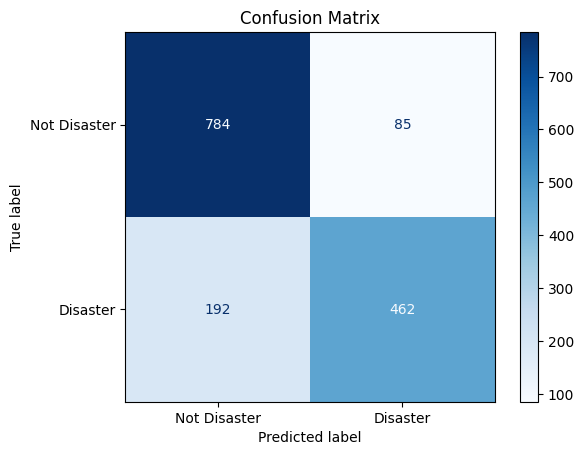

In [29]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.4f}")
precision = precision_score(y_test, y_pred)

print(f"Precision : {precision:.4f}")
f1 = f1_score(y_test, y_pred)

print(f"F1 Score : {f1:.4f}")
recall = recall_score(y_test, y_pred)

print(f"Recall : {recall:.4f}")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Not Disaster","Disaster"]
))

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Disaster","Disaster"]
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

In [30]:
def predict_disaster(tweet):

    cleaned = clean_text(tweet)

    vector = vectorizer.transform([cleaned])

    prediction = model.predict(vector)[0]

    probability = model.predict_proba(vector)[0][1]

    print("\nTweet:")
    print(tweet)

    print("\nCleaned:")
    print(cleaned)

    print("\nPrediction:")

    if prediction == 1:
        print(" Disaster Tweet")
    else:
        print(" Not a Disaster Tweet")



In [31]:
predict_disaster(
    "Massive earthquake destroys hundreds of homes in Japan."
)

predict_disaster(
    "Going shopping with friends this evening!"
)

predict_disaster(
    "Flash flood warning issued for Mumbai tonight."
)


Tweet:
Massive earthquake destroys hundreds of homes in Japan.

Cleaned:
massive earthquake destroys hundred home japan

Prediction:
 Disaster Tweet

Tweet:
Going shopping with friends this evening!

Cleaned:
going shopping friend evening

Prediction:
 Not a Disaster Tweet

Tweet:
Flash flood warning issued for Mumbai tonight.

Cleaned:
flash flood warning issued mumbai tonight

Prediction:
 Disaster Tweet


In [32]:
import pandas as pd

metrics_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",

    ],
    "Score": [
        round(accuracy, 4),
        round(precision, 4),
        round(recall, 4),
        round(f1, 4),

    ]
})

metrics_df


,Metric,Score
0,Accuracy,0.8181
1,Precision,0.8446
2,Recall,0.7064
3,F1-Score,0.7694
